## 1. Veriyi Yükle

In [1]:
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_csv("CAvideos.csv")

## 2. Veri Keşfi (EDA)

In [2]:
df.shape

(40881, 16)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40881 entries, 0 to 40880
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                40881 non-null  object
 1   trending_date           40881 non-null  object
 2   title                   40881 non-null  object
 3   channel_title           40881 non-null  object
 4   category_id             40881 non-null  int64 
 5   publish_time            40881 non-null  object
 6   tags                    40881 non-null  object
 7   views                   40881 non-null  int64 
 8   likes                   40881 non-null  int64 
 9   dislikes                40881 non-null  int64 
 10  comment_count           40881 non-null  int64 
 11  thumbnail_link          40881 non-null  object
 12  comments_disabled       40881 non-null  bool  
 13  ratings_disabled        40881 non-null  bool  
 14  video_error_or_removed  40881 non-null  bool  
 15  de

In [4]:
df.describe()

,category_id,views,likes,dislikes,comment_count
count,40881.000000,4.088100e+04,4.088100e+04,4.088100e+04,4.088100e+04
mean,20.795553,1.147036e+06,3.958269e+04,2.009195e+03,5.042975e+03
std,6.775054,3.390913e+06,1.326895e+05,1.900837e+04,2.157902e+04
min,1.000000,7.330000e+02,0.000000e+00,0.000000e+00,0.000000e+00
25%,20.000000,1.439020e+05,2.191000e+03,9.900000e+01,4.170000e+02
50%,24.000000,3.712040e+05,8.780000e+03,3.030000e+02,1.301000e+03
75%,24.000000,9.633020e+05,2.871700e+04,9.500000e+02,3.713000e+03
max,43.000000,1.378431e+08,5.053338e+06,1.602383e+06,1.114800e+06


In [5]:
df.isnull().sum()

video_id                     0
trending_date                0
title                        0
channel_title                0
category_id                  0
publish_time                 0
tags                         0
views                        0
likes                        0
dislikes                     0
comment_count                0
thumbnail_link               0
comments_disabled            0
ratings_disabled             0
video_error_or_removed       0
description               1296
dtype: int64

In [6]:
df.dtypes

video_id                  object
trending_date             object
title                     object
channel_title             object
category_id                int64
publish_time              object
tags                      object
views                      int64
likes                      int64
dislikes                   int64
comment_count              int64
thumbnail_link            object
comments_disabled           bool
ratings_disabled            bool
video_error_or_removed      bool
description               object
dtype: object

In [7]:
df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,n1WpP7iowLc,17.14.11,Eminem - Walk On Water (Audio) ft. Beyoncé,EminemVEVO,10,2017-11-10T17:00:03.000Z,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/In...",17158579,787425,43420,125882,https://i.ytimg.com/vi/n1WpP7iowLc/default.jpg,False,False,False,Eminem's new track Walk on Water ft. Beyoncé i...
1,0dBIkQ4Mz1M,17.14.11,PLUSH - Bad Unboxing Fan Mail,iDubbbzTV,23,2017-11-13T17:00:00.000Z,"plush|""bad unboxing""|""unboxing""|""fan mail""|""id...",1014651,127794,1688,13030,https://i.ytimg.com/vi/0dBIkQ4Mz1M/default.jpg,False,False,False,STill got a lot of packages. Probably will las...
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146035,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...
3,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095828,132239,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...
4,2Vv-BfVoq4g,17.14.11,Ed Sheeran - Perfect (Official Music Video),Ed Sheeran,10,2017-11-09T11:04:14.000Z,"edsheeran|""ed sheeran""|""acoustic""|""live""|""cove...",33523622,1634130,21082,85067,https://i.ytimg.com/vi/2Vv-BfVoq4g/default.jpg,False,False,False,🎧: https://ad.gt/yt-perfect\n💰: https://atlant...


## 3. Veri Temizleme ve Dönüştürme

In [8]:
with open("CA_category_id.json", "r") as f:
    veri=json.load(f)

In [9]:
kategori_sozlugu={}
for item in veri["items"]:
    category_id=int(item["id"])
    category_title=item["snippet"]["title"]
    kategori_sozlugu[category_id]=category_title

In [10]:
df["category_name"]=df["category_id"].map(kategori_sozlugu)

In [11]:
df["category_name"]=df["category_name"].fillna("Unknown")

In [12]:
views_median=df["views"].median()
interaction_threshold=500

In [13]:
mask=(
    (df["views"]> views_median) & 
    ((df["likes"]+df["dislikes"]) > interaction_threshold) &
    (df["dislikes"] > 0)
)

In [14]:
df_filtered = df[mask].copy()

In [15]:
df_filtered['likability_score'] = df_filtered['likes'] / (df_filtered['likes'] + df_filtered['dislikes'])

In [16]:
df.loc[mask, 'likability_score'] = df['likes'] / (df['likes'] + df['dislikes'])

## 4. Analiz ve Görselleştirme

<Axes: title={'center': 'En Çok İzlenen 10 Kanal'}, xlabel='Kanal İsimleri', ylabel='İzlenme Rakamları'>

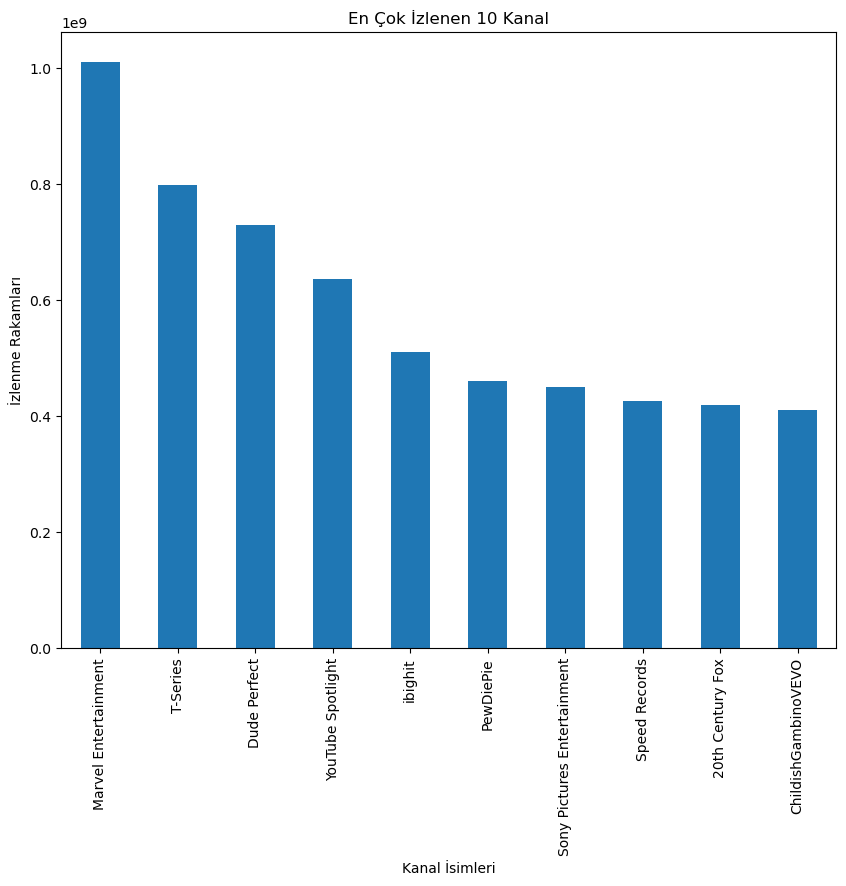

In [17]:
# En çok izlenen 10 kanal hangisi?
ten_most_view_channel=df.groupby("channel_title")["views"].sum().sort_values(ascending=False).head(10)
ten_most_view_channel.plot(figsize=(10,8),kind="bar", title="En Çok İzlenen 10 Kanal", xlabel="Kanal İsimleri", ylabel="İzlenme Rakamları")

title
BTS (방탄소년단) 'FAKE LOVE' Official MV                          23078610
Marvel Studios' Avengers: Infinity War Official Trailer      18929848
YouTube Rewind: The Shape of 2017 | #YouTubeRewind           16687951
Childish Gambino - This Is America (Official Video)          14593916
Drake - God’s Plan                                           12164958
Maroon 5 - Girls Like You ft. Cardi B                         9820458
Ariana Grande - No Tears Left To Cry                          9696468
Marvel Studios' Avengers: Infinity War - Official Trailer     9466506
BTS (방탄소년단) 'MIC Drop (Steve Aoki Remix)' Official MV         9373576
Taylor Swift - End Game ft. Ed Sheeran, Future                9282504
Name: likes, dtype: int64


C:\Users\asus\AppData\Roaming\Python\Python313\site-packages\IPython\core\events.py:96: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\asus\AppData\Roaming\Python\Python313\site-packages\IPython\core\events.py:96: UserWarning: Glyph 53444 (\N{HANGUL SYLLABLE TAN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\asus\AppData\Roaming\Python\Python313\site-packages\IPython\core\events.py:96: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\asus\AppData\Roaming\Python\Python313\site-packages\IPython\core\events.py:96: UserWarning: Glyph 45380 (\N{HANGUL SYLLABLE NYEON}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\asus\AppData\Roaming\Python\Python313\site-packages\IPython\core\events.py:96: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\asus

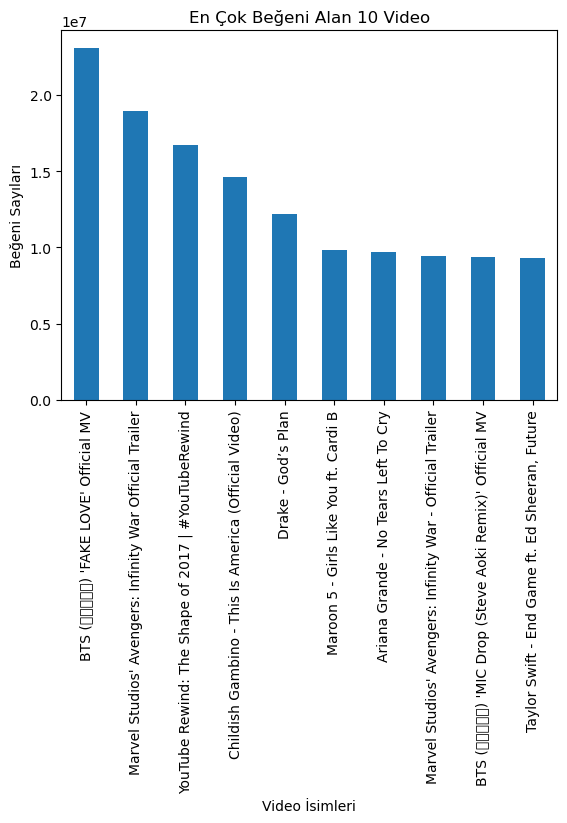

In [18]:
# En çok like alan 10 video hangisi?
most_liked_ten_videos=df.groupby("title")["likes"].sum().sort_values(ascending=False).head(10)
most_liked_ten_videos.plot(kind="bar", xlabel="Video İsimleri", ylabel="Beğeni Sayıları", title="En Çok Beğeni Alan 10 Video")
print(most_liked_ten_videos)

<Axes: title={'center': 'En Çok İzlenen 10 Kategori'}, xlabel='Kategoriler', ylabel='İzlenmeler'>

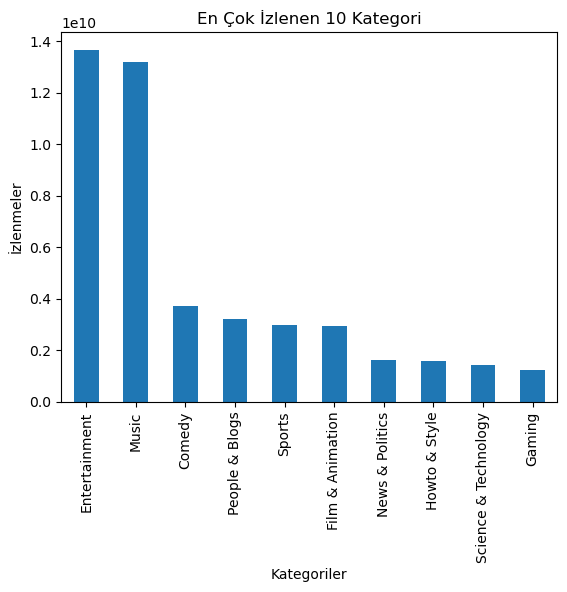

In [19]:
# En çok izlenen 10 kategori
most_watch_ten_categories=df.groupby("category_name")["views"].sum().sort_values(ascending=False).head(10)
most_watch_ten_categories.plot(kind="bar", xlabel="Kategoriler", ylabel="İzlenmeler", title="En Çok İzlenen 10 Kategori")

<Axes: xlabel='views', ylabel='likes'>

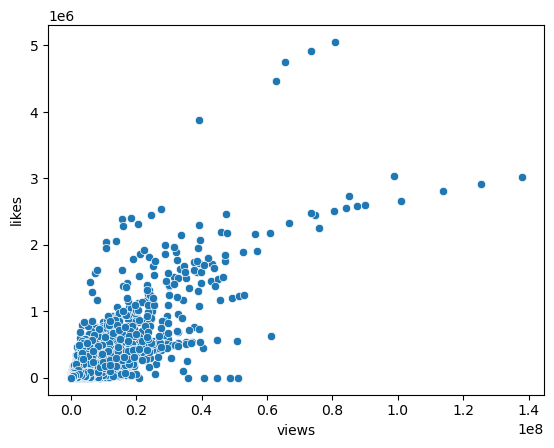

In [20]:
# Like ile view arasında ilişki var mı? (scatter plot)
sns.scatterplot(data=df, x=df["views"], y=df["likes"])

<Axes: xlabel='comment_count', ylabel='likes'>

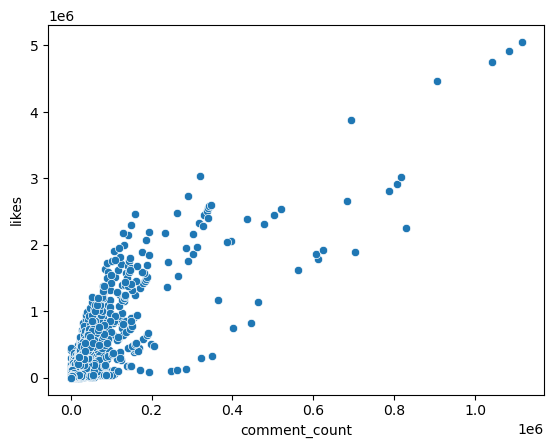

In [21]:
# Yorum sayısı ile like arasında ilişki var mı?
sns.scatterplot(data=df, x=df["comment_count"], y=df["likes"])

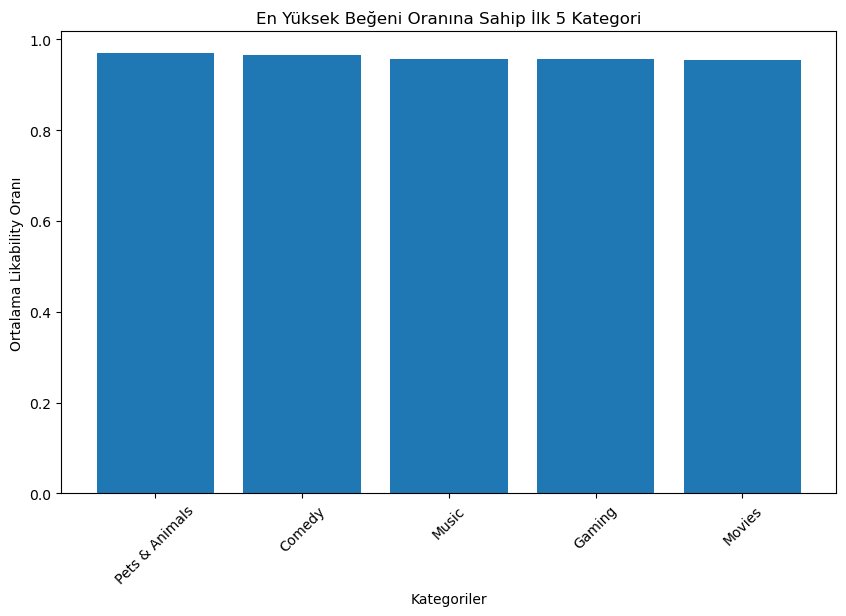

In [22]:
likability_score_average_per_category=df.groupby("category_name")["likability_score"].mean().sort_values(ascending=False).head(5)
fig, ax= plt.subplots(figsize=(10,6))
ax.bar(likability_score_average_per_category.index, likability_score_average_per_category.values)
ax.set_xlabel('Kategoriler')
ax.set_ylabel('Ortalama Likability Oranı')
ax.set_title("En Yüksek Beğeni Oranına Sahip İlk 5 Kategori")
plt.xticks(rotation=45) 

plt.show()

<Axes: >

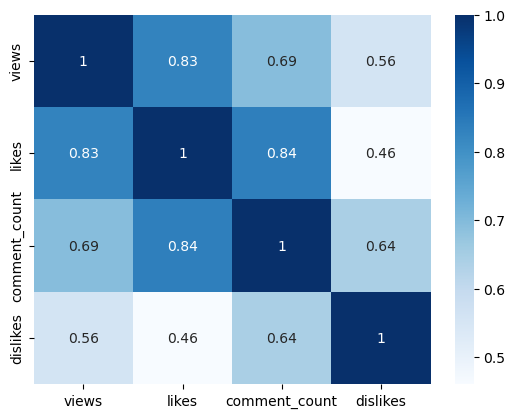

In [24]:
sns.heatmap(df[["views", "likes", "comment_count", "dislikes"]].corr(), annot=True, cmap="Blues")

## Sonuçlar
Yapılan analizler sonucunda en çok izlenen kanalın Marvel Entertainment olduğu tespit edilmiştir. En çok beğeni alan video ise 23078610 Like sayısıyla "BTS (방탄소년단) 'FAKE LOVE' Official MV" olmuştur. Entertainment ve Music kategorileri açık ara diğer kategorilere göre daha çok izlenmiştir. En yüksek beğeni oranına sahip kategoriler ise Pets & Animals, Comedy, Music, Gaming, Movies olmuştur. views - likes= 0.828964 ve comment_count - likes = 0.836585 yani sonuçlar gösteriyor ki hem görüntülenmenin hemde yorum sayısının beğeni oranlarıyla güçlü pozitif ilişkisi olduğunu anlıyoruz.